# Checkerboard data analysis

Contact: laquitainesteeve@gmail.com based on Guilhelm's guilhelm-dev branch  

Description: This notebook is the second one of the Analysis Pipeline. If you haven't run the first one (Preprocessing) until the extraction of phy's data , you don't have the files needed to run this one. In this notebook, you will use phy sorted cluster spikes of a checkerboard recording to compute clusters raster plots, ganglion cells STA and fit ellipses on their receptive fields.

Execution time: 9 min

Tested on Ubuntu 24.04.1 LTS (32 cores, 188 GB RAM, Intel(R) Core(TM) i9-14900K ＠3.2 GHz/5.8 GHz)


**Required by**:
- 4-Chirp+Cell Typing.ipynb notebook

## Setup

1. Create, activate (env/..yml) and setup the virtual environment :

    ```python
    python -m ipykernel install --user --name standard_analysis_pipeline --display-name "standard_analysis_pipeline"
    ```

2. Configure your experiment in ./params.py

In [9]:
%load_ext autoreload
%autoreload 2

# import packages
import os
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import curve_fit
from scipy.ndimage import convolve
from matplotlib.gridspec import GridSpec
from PIL import Image

# import custom packages
import params
from utils_analyse_checkerboard import * # <-- steeve modified [TODO!] to merge in a single utils?

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Functions

In [ ]:
# experiment design 

def get_inputs(params: dict):
    """Get the parameters of the checkerboard experiment

    Args:
        params (dict): parameters of the experiments as 
        ... specified in params.py
    
    Returns:
        recording_number (TODO!): TODO!
        stimulus_frequency (TODO!): TODO!
        nb_checks_x (TODO!): TODO!
        check_directory (TODO!): TODO!

    Warning: 
        do not change values here unless debug/specific use!
    """
    # Getting the recording name
    print('Which of the following is the checkerboard: ')

    # Map the names of each recording to a number
    for num, rec in enumerate(params.recording_names):
        print(f'\t{num} --> {rec}')

    # ask the user to input the selected recording number
    recording_number = int(input('Checkerboard number : '))
    params.checkerboard_name = params.recording_names[recording_number]
    print('Selected recording: {}\n'.format(params.checkerboard_name))

    # ask the user to input the stimulus frequency
    stimulus_frequency = int(input("Select stimulus frequency (usually 30Hz) : "))

    # ask the user to input the number of checks used on the checkerboard
    nb_checks_x = int(input("Select number of checks on x (usually 40 for fine checkerboard) : "))
    nb_checks_y = int(input("Select number of checks on y (usually 40 for fine checkerboard) : "))
    
    # check that the checkerboard analysis path exists, else create it
    check_directory = os.path.normpath(os.path.join(params.output_directory,r'Checkerboard_Analysis_rec_{}'.format(recording_number)))
    if not os.path.isdir(check_directory): 
        os.makedirs(check_directory)
    return recording_number, stimulus_frequency, nb_checks_x, nb_checks_y, check_directory


def load_checkerboard_experiment_data(params: dict, check_directory, nb_checks_x, nb_checks_y):
    """Process the checkerboard experiment data

    Args:
        params (dict): parameters of the experiments as 
        ... specified in params.py

    Returns:
        checkerboard_spikes (TODO!): TODO!
        triggers (TODO!): TODO!
        nb_repeats (TODO!): TODO!
        cells_id (TODO!): TODO!
    """
    # load the checkerboard file where the triggers were recorded
    triggers_file = os.path.normpath(os.path.join(
        params.triggers_directory,r"{}_{}_triggers.pkl".format(
            params.exp, 
            params.checkerboard_name)
            ))
    triggers_data = load_obj(triggers_file)

    # load the file where the spikes of all the recordings of 
    # the experiment are saved
    neurons_file  = os.path.normpath(os.path.join(
        params.output_directory,
        r'{}_fullexp_neurons_data.pkl'.format(params.exp)))
    all_recs_spikes = load_obj(neurons_file)

    # keep only the spikes recorded during the checkerboard experiment
    checkerboard_spikes = get_recording_spikes(params.checkerboard_name, all_recs_spikes)

    # get the ids of the cells that produced these spikes
    cells_id = list(checkerboard_spikes.keys())

    # get the triggers
    triggers = triggers_data['indices']/params.fs

    # get the number of repeats
    nb_repeats = int(len(triggers)/params.nb_frames_by_sequence)

    # get the duration of a sequence
    duration_sequence = int(params.nb_frames_by_sequence/stimulus_frequency)

    # report experiment parameters
    print("\nCheckerboard Stats :\n\t- {} min total duration \n\t- {} triggers \n\t- {} complete sequences\n\t- {} seconds per sequence\n".format(
        int(triggers_data['duration']/params.fs/60),len(triggers),
        nb_repeats, duration_sequence))

    # get the number of frames
    nb_frames = int((nb_repeats)*int(params.nb_frames_by_sequence/2))

    # get the stimulus path
    stimulus_path = os.path.normpath(os.path.join(
        check_directory, "checkerboard_{}x{}checks_{}frames.npy".format(nb_checks_x, 
                                                                        nb_checks_y, 
                                                                        nb_frames)))

    # check that the stimulus files exists, load it
    if os.path.isfile(stimulus_path):
        print("Stimulus file exists. Loaded from :\t {}".format(stimulus_path))
        checkerboard = np.load(stimulus_path)
    else:
        # else save
        print("Reconstructing the stimulus...")
        checkerboard = checkerboard_from_binary(
            nb_frames, nb_checks_x, nb_checks_y, 
            checkerboard_file=stimulus_path, 
            binary_source_path=params.binary_source_path
            )

    # report 
    print('Total : {} neurons loaded \n\nClusters id :\n{}\n'.format(len(checkerboard_spikes.keys()), cells_id))
    return checkerboard_spikes, triggers, nb_repeats, cells_id, checkerboard

# rasters and psths ---------------

def compute_rasters(checkerboard_spikes, triggers, nb_repeats, stimulus_frequency):

    # initialiser raster output
    raster_data = {}

    # report status
    print('Computing rasters...')

    # loop over the spikes recorded during the checkerboard experiment
    # get the rasters on repeated sequence
    for (cell_id, spike_times) in tqdm(checkerboard_spikes.items()):
        raster_data[cell_id] = extract_from_sequence(spike_times, triggers, nb_repeats, stim_frequency = stimulus_frequency)
    return raster_data


def plot_rasters(raster_data, cells_id, ploting:bool=True):

    # Plot all the rasters. Takes a few seconds.
    if ploting:
        size = int(math.sqrt(len(cells_id)))+1

        # setup subplots
        fig, axs = plt.subplots(nrows = size, ncols=size, figsize = (50,50))
        print('Ploting...')
        for i in tqdm(range(size**2)):
            ax = axs[i//size,i%size]
            if i < len(cells_id):
                ax.eventplot(raster_data[cells_id[i]]["spike_trains"])
                ax.set(title = "Cell {}".format(cells_id[i]),xlabel='Time in sec', ylabel='N Repetitions')
            else : ax.set_visible(False)

        # format and close
        plt.tight_layout()
        plt.show(block=False)
        plt.close('all')


def save_plots(raster_data, cells_id, recording_number:int, 
               check_directory:str, params:dict):
    """Create a folder path with the saved raster and 
    psths plots, a file per cell.
    
    Args:
        raster_data
        cells_id
        recording_number (int): 
        check_directory (str):
        params (dict):

    Returns:
    """
    # report status
    print("Saving rasters ...")
    
    # figure path
    fig_directory = os.path.normpath(os.path.join(
        check_directory, r'Rasters_figs'.format(recording_number)))
    
    # ensure path figure exists
    if not os.path.isdir(fig_directory): 
        os.makedirs(fig_directory)
    
    # loop over cells
    for cell_nb in tqdm(cells_id):

        # setup subplots
        fig, axs = plt.subplots(nrows = 2,ncols = 1, sharex=True, gridspec_kw={'height_ratios': [3, 1]}, figsize=(10,10))

        # add title
        plt.suptitle(f'Cell {cell_nb}')
        
        # plot raster
        ax_rast = axs[0]
        ax_rast.eventplot(raster_data[cell_nb]["spike_trains"])
        ax_rast.set(title = "Raster plot", ylabel='N Repetitions')

        # plot firing rate psth
        ax_psth = axs[1]
        width = (raster_data[cell_nb]["repeated_sequences_times"][0][0]/int(params.nb_frames_by_sequence/2))
        seq_lenght = raster_data[cell_nb]["repeated_sequences_times"][0][1]-raster_data[cell_nb]["repeated_sequences_times"][0][0]
        ax_psth.bar(np.linspace(0, seq_lenght, int(params.nb_frames_by_sequence/2)) + width/2, 
                    raster_data[cell_nb]["psth"], width=1.3*width)
        ax_psth.set(xlabel='Time in sec', ylabel='Firing rate (spikes/s)')

        # format figure
        plt.subplots_adjust(wspace=0, hspace=0)

        # save figure
        fig_file = os.path.join(fig_directory,f'Cell_{cell_nb}.png')
        plt.savefig(fig_file, dpi=fig.dpi)

        # clear and close figure
        plt.clf()
        plt.close()
    
    # save raster data
    np.save(os.path.join(check_directory,'Check_rasters_data'), raster_data)


def plot_one_cell_raster_and_psth(raster_data, checkerboard_spikes, cells_id, params: dict):

    # report number of neurons
    print('Total : {} neurons found \n\nClusters id :\n{}\n'.format(len(checkerboard_spikes.keys()), cells_id))

    # ask the user to select a cell
    cell_nb = int(input("Select a cell: "))

    # setup plot
    fig, axs = plt.subplots(
        nrows = 2, ncols = 1, 
        sharex=True, 
        gridspec_kw={'height_ratios': [3, 1]}, 
        figsize=(10, 10))

    # plot raster
    ax_rast = axs[0]
    ax_rast.eventplot(raster_data[cell_nb]["spike_trains"])
    ax_rast.set(title = "Raster plot", ylabel='N Repetitions')

    # plot psth
    ax_psth = axs[1]
    width = (raster_data[cell_nb]["repeated_sequences_times"][0][0]/int(params.nb_frames_by_sequence/2))
    seq_lenght = raster_data[cell_nb]["repeated_sequences_times"][0][1] - raster_data[cell_nb]["repeated_sequences_times"][0][0]
    ax_psth.bar(
        np.linspace(0,seq_lenght, int(params.nb_frames_by_sequence/2))+width/2, 
        raster_data[cell_nb]["psth"], width=1.3*width)
    ax_psth.set(xlabel='Time in sec', ylabel='Firing rate (spikes/s)')

    # format
    plt.suptitle(f'Cell {cell_nb}')
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show(block=False)
    
    # close
    plt.close(fig)

# spike triggered averages ---------------

def compute_spike_triggered_average(checkerboard_spikes, checkerboard, 
                                    triggers, nb_repeats, stimulus_frequency, 
                                    sequence_portion=(0, 0.5), 
                                    sta_data_filename = 'sta_data_3D.pkl'):

    # report status
    print('Computing STAs...')

    # initialize sta output
    sta_data = {}

    # loop over spikes of checkerboard experiment
    for (cell_id, spike_times) in tqdm(checkerboard_spikes.items()):
        
        # Get spikes on random sequences
        sta_data[cell_id] = extract_from_sequence(spike_times, triggers, nb_repeats, stimulus_frequency, sequence_portion=sequence_portion)
        
        # Compute sta of the cell
        sta_3D = compute_3D_sta(sta_data[cell_id], checkerboard, stimulus_frequency, cluster_id=cell_id) 
        
        # Adding data to the notebook dictionnary
        sta_data[cell_id]['sta_3D'] = sta_3D

    # save
    sta_data_file = os.path.normpath(os.path.join(check_directory, sta_data_filename))
    save_obj(sta_data,sta_data_file)
    return sta_data_file, sta_data


def plot_one_cell_3D_spike_triggered_average(sta_data, checkerboard_spikes, cells_id):

    # report number of cells
    print('Total : {} neurons found \n\nClusters id :\n{}\n'.format(len(checkerboard_spikes.keys()), cells_id))
    
    # ask user to input a cell
    cell_id = int(input("Select a cell: "))

    # plot
    fig = plt.figure(figsize=(10,10))
    gs = GridSpec(8, 5, figure=fig)
    for i in range(40):
        ax = fig.add_subplot(gs[i//5,i%5])
        ax.imshow(sta_data[cell_id]['sta_3D'][i])
    plt.show(block=False)
    plt.close(fig)


def fit_ellipse_to_spike_triggered_average(
    checkerboard, 
    check_directory: str, 
    method: str="tom", 
    fitted_sta_filename='sta_data_3D_fitted.pkl'):

    """fit ellipse to STA
    
    Args:
        checkerboard (TODO!): TODO!
        check_directory (str): TODO!
        method (str): fitting method : 'tom', 'matias', 'gab' or 'basic'
    
    Returns:
        saves fitted STA data
    """
    # File loading the 3D sta dictionnary saved above in this notebook
    sta_data_file = os.path.normpath(os.path.join(check_directory, 'sta_data_3D.pkl'))
    sta_data = load_obj(sta_data_file)

    # loop over cells
    for cell_id in tqdm(sta_data):

        # get 3D sta
        sta_3D = sta_data[cell_id]['sta_3D']
        
        if np.max(np.abs(sta_3D)) == 0:
            print(f'No ellipse fit on cell {cell_id}')
            sta_data[cell_id]["center_analyse"]   = {'Spatial':np.zeros(checkerboard[0].shape), 'Temporal':np.zeros(checkerboard.shape[0]), 'EllipseCoor':np.asarray([0, 0, 0, 0.001, 0.001, 0]), 'Cell_delay':np.nan}
            sta_data[cell_id]["surround_analyse"] = {'Spatial':np.zeros(checkerboard[0].shape), 'Temporal':np.zeros(checkerboard.shape[0]), 'EllipseCoor':np.asarray([0, 0, 0, 0.001, 0.001, 0]), 'Cell_delay':np.nan}
            sta_data[cell_id]["analyse_sta"]      = {'Spatial':np.zeros(checkerboard[0].shape), 'Temporal':np.zeros(checkerboard.shape[0]), 'EllipseCoor':np.asarray([0, 0, 0, 0.001, 0.001, 0]), 'Cell_delay':np.nan}

            continue
        
        # Perform the fitting for the current cell using one of the bellow method (default "analyse_sta_matias")
        if method=='tom':
            # New fitting of ellipse, more performant
            sta_data[cell_id]["center_analyse"] = analyse_sta_tom(sta_3D, cell_id) 
        elif method=='matias':
            sta_data[cell_id]["center_analyse"] = analyse_sta_matias(sta_3D, cell_id)
        elif method=='gab':
            sta_data[cell_id]["surround_analyse"] = analyse_sta_gab(sta_3D, cell_id)
        elif method=='basic':
            sta_data[cell_id]["analyse_sta"]= analyse_sta(sta_3D, cell_id)

    # ouput file of all fitted data
    fitted_file = os.path.normpath(os.path.join(check_directory, fitted_sta_filename))

    # save file
    save_obj(sta_data, fitted_file)


def plot_sta_fitted_with_ellipse(cells_id, cells_to_plot:list, check_directory:str):
        
    # Folder where figure will be saved
    fig_directory = os.path.normpath(os.path.join(check_directory,r'Stas_figs'))
    if not os.path.isdir(fig_directory): os.makedirs(fig_directory)

    # load sta
    sta_data = np.load(os.path.join(check_directory, 'sta_data_3D_fitted.pkl'), allow_pickle=True)

    # loop over all cells
    for cell_id in tqdm(cells_id[0:]):

        # get cell sta data
        sta = sta_data[cell_id]["center_analyse"]

        # setup subplots
        fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize=(15,7))

        # add title
        plt.suptitle(f'Cell {cell_id}')
        
        # plot spatial sta
        ax = axs[0]
        ax.imshow(sta['Spatial'])
        ax.set(title = "Spatial STA")

        # plot fitted ellipse
        ax = axs[1]
        ax.set(title = "Fitted Ellipse")

        try:
            ax = plot_sta(ax, sta['Spatial'], sta['EllipseCoor'])
        except:
            ax.imshow(sta_data[cell_id]["center_analyse"]['Spatial'])

        fig_file = os.path.join(fig_directory,f'Cell_{cell_id}.png')

        # save figure
        plt.savefig(fig_file, dpi=fig.dpi)

        # plot selected cells only
        if cell_id in cells_to_plot:
            plt.show()
        
        # close figure to free memory
        plt.close(fig)


def plot_sta_fitted_with_ellipse_by_tom(raster_data, cells_id, check_directory):

    # Folder where figure will be saved
    fig_directory = os.path.normpath(os.path.join(check_directory, r'Stas_figs'))
    if not os.path.isdir(fig_directory): os.makedirs(fig_directory)

    sta_data=np.load(os.path.join(check_directory,'sta_data_3D_fitted.pkl'),allow_pickle=True)

    for cell_id in tqdm(cells_id[0:]):
        fig, axs = plt.subplots(nrows = 1,ncols = 3, figsize=(30,10))

        plt.suptitle(f'Cell {cell_id}')
        sta=sta_data[cell_id]["center_analyse"]
        ax = axs[0]
        ax.eventplot(raster_data[cell_id]["spike_trains"])
        ax.set(title = "Raster plot", ylabel='N Repetitions')

        ax = axs[1]
        ax.set(title = "Fitted Ellipse")

        try:
            ax = plot_sta_tom(ax, sta['Spatial'],sta['EllipseCoor'])
        except: 
            ax.imshow(sta_data[cell_id]["center_analyse"]['Spatial'])

        ax=axs[2]
        ax.set(title = "Temporal STA")
        ax.plot(sta['Temporal'])
        ax.set_ylim([-1,1])

        fig_file = os.path.join(fig_directory,f'Cell_{cell_id}.png')
        plt.savefig(fig_file, dpi=fig.dpi)
        plt.show()
        plt.clf()
        plt.close()

## Load data

- All the variables used in this part of the cell should always refer to your 'params.py' file, unless you want to manually change them only for this run (i.e. debugging). You may have to add those variable into the function you want to adapt as only the minimal amount of var are currently given to functions as inputs.
- Mandatory for each run !
- Execution time: 9 secs

In [11]:
%%time 

# ask user to input the experiment parameters
# e.g., for the test dataset enter inputs: 0, 30, 42, 42
recording_number, stimulus_frequency, nb_checks_x, nb_checks_y, check_directory = get_inputs(params)

# load checkerboard experiment data
checkerboard_spikes, triggers, nb_repeats, cells_id, checkerboard = load_checkerboard_experiment_data(params, check_directory, nb_checks_x, nb_checks_y)

Which of the following is the checkerboard: 
	0 --> 00_AccCheck_30Hz_16px_42sq_50%30ND
	1 --> 01_Swn_30Hz_48pxCh_6pxL_50%30ND
	2 --> 02_Chirp_50Hz_50%30ND
	3 --> 03_DG_50Hz_50%30ND
	4 --> 04_PulsingGratings-PS0_40Hz_50%30ND
	5 --> 05_PulsingGratings-PS1_40Hz_50%30ND
	6 --> 06_PulsingGratings-PS2_40Hz_50%30ND


Selected recording: 00_AccCheck_30Hz_16px_42sq_50%30ND


Checkerboard Stats :
	- 37 min total duration 
	- 66728 triggers 
	- 55 complete sequences
	- 40 seconds per sequence

Stimulus file exists. Loaded from :	 data/20251219_PulsingGratings_PupilSize/Analysis/Checkerboard_Analysis_rec_0/checkerboard_42x42checks_33000frames.npy
Total : 344 neurons loaded 

Clusters id :
[np.uint32(0), np.uint32(1), np.uint32(2), np.uint32(3), np.uint32(4), np.uint32(5), np.uint32(6), np.uint32(7), np.uint32(8), np.uint32(9), np.uint32(10), np.uint32(11), np.uint32(12), np.uint32(13), np.uint32(14), np.uint32(15), np.uint32(16), np.uint32(17), np.uint32(18), np.uint32(19), np.uint32(20), np.uint32(21), np.uint32(22), np.uint32(23), np.uint32(24), np.uint32(25), np.uint32(26), np.uint32(27), np.uint32(28), np.uint32(29), np.uint32(30), np.uint32(31), np.uint32(32), np.uint32(33), np.uint32(34), np.uint32(35), np.uint32(36), np.uint32(37), np.uint32(38), np.uint32(39), np.uint32(40), np.uint32(41), np.ui

## Plot Rasters & PSTH

- Analysis on repeated sequence: all the variables used in this part of the cell should always refere to your 'params.py' file
unless you want to manually change them only for this run (i.e. debugging). 
You may have to add those variable into the function you want to adapt as only the minimal 
amount of var are currently given to functions as inputs.
- Requirements: cell 1 run
- Execution time: < 3 mins

Computing rasters...


100%|██████████| 344/344 [00:00<00:00, 657.52it/s]


Ploting...


100%|██████████| 361/361 [00:06<00:00, 53.49it/s]


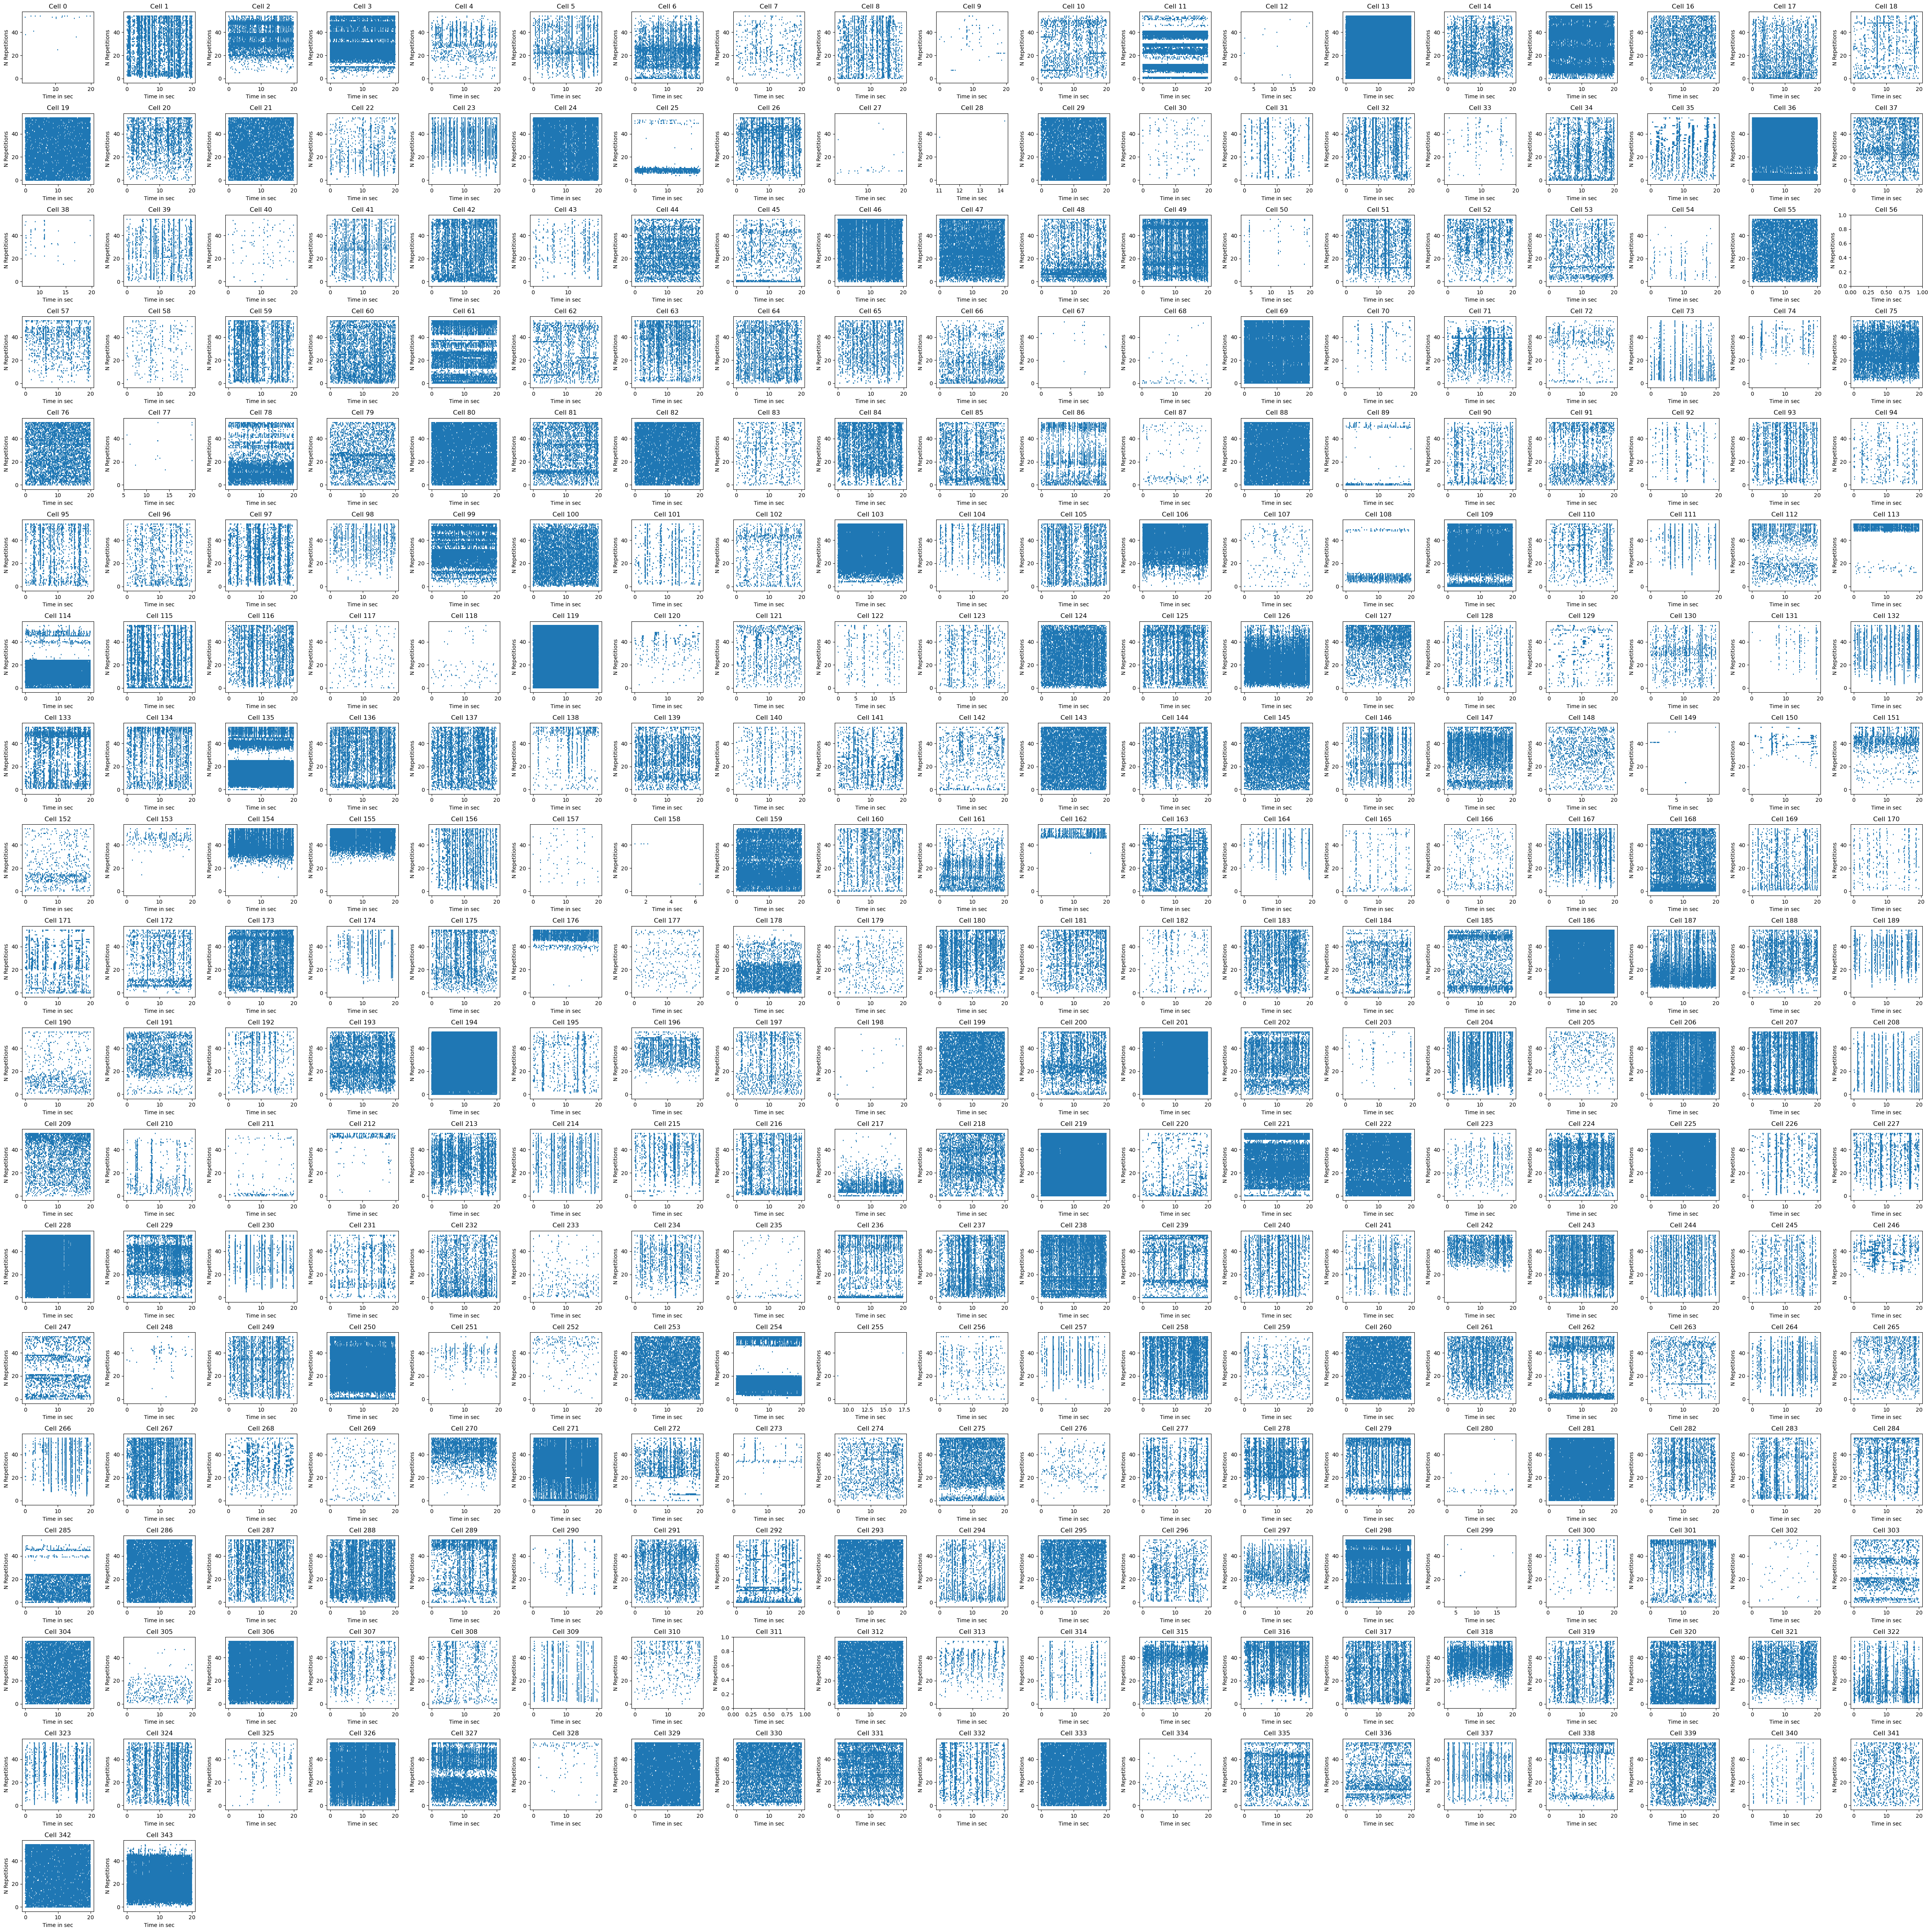

Saving rasters ...


100%|██████████| 344/344 [01:46<00:00,  3.22it/s]

CPU times: user 2min 7s, sys: 1.04 s, total: 2min 8s
Wall time: 2min 7s


In [12]:
%%time

# inputs    
ploting = True      # plot or not 
save_fig = True     # save plots or not

# compute rasters
raster_data = compute_rasters(checkerboard_spikes, triggers, nb_repeats, stimulus_frequency)

# plot rasters
plot_rasters(raster_data, cells_id, ploting=ploting)

# save plots
if save_fig:
    save_plots(raster_data, cells_id, recording_number, 
               check_directory, params)

## Check each cell

Total : 344 neurons found 

Clusters id :
[np.uint32(0), np.uint32(1), np.uint32(2), np.uint32(3), np.uint32(4), np.uint32(5), np.uint32(6), np.uint32(7), np.uint32(8), np.uint32(9), np.uint32(10), np.uint32(11), np.uint32(12), np.uint32(13), np.uint32(14), np.uint32(15), np.uint32(16), np.uint32(17), np.uint32(18), np.uint32(19), np.uint32(20), np.uint32(21), np.uint32(22), np.uint32(23), np.uint32(24), np.uint32(25), np.uint32(26), np.uint32(27), np.uint32(28), np.uint32(29), np.uint32(30), np.uint32(31), np.uint32(32), np.uint32(33), np.uint32(34), np.uint32(35), np.uint32(36), np.uint32(37), np.uint32(38), np.uint32(39), np.uint32(40), np.uint32(41), np.uint32(42), np.uint32(43), np.uint32(44), np.uint32(45), np.uint32(46), np.uint32(47), np.uint32(48), np.uint32(49), np.uint32(50), np.uint32(51), np.uint32(52), np.uint32(53), np.uint32(54), np.uint32(55), np.uint32(56), np.uint32(57), np.uint32(58), np.uint32(59), np.uint32(60), np.uint32(61), np.uint32(62), np.uint32(63), np.uint

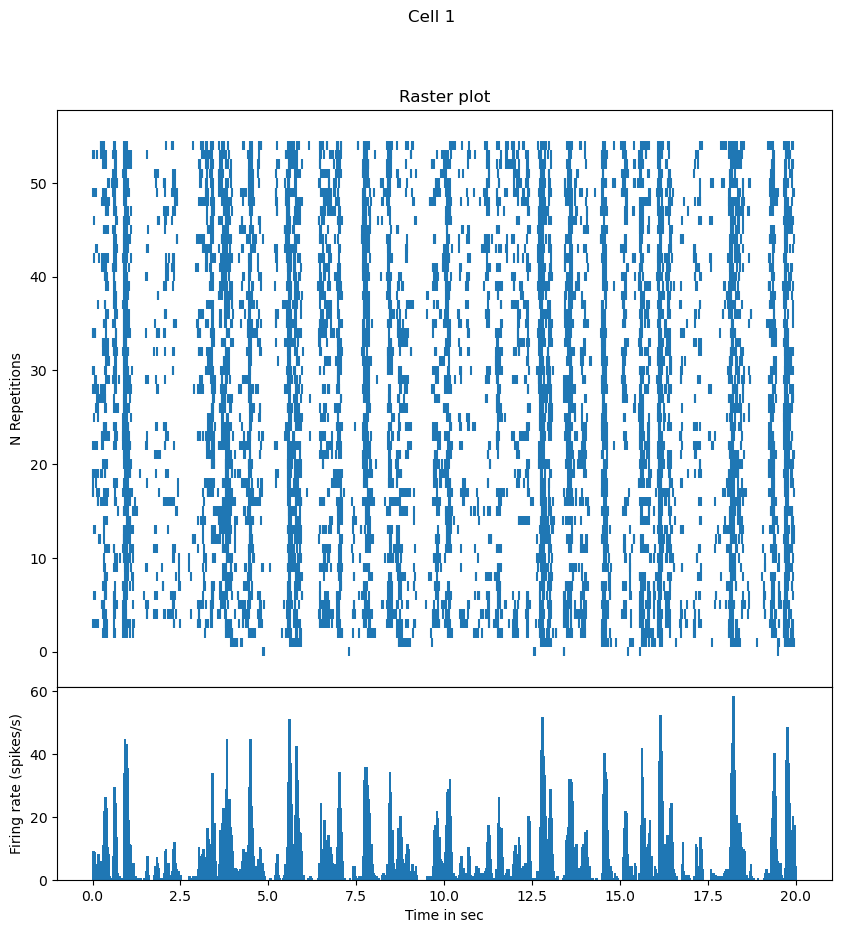

CPU times: user 368 ms, sys: 3.02 ms, total: 371 ms
Wall time: 2.04 s


In [22]:
%%time

# ask the user to select a cell and plot its raster and psth (e.g., 1)
plot_one_cell_raster_and_psth(raster_data, checkerboard_spikes, cells_id, params)

## Compute STA

- **Requirements**: requires cell 1 run
- Execution time: < 5 min

In [14]:
%%time 

# compute sta
sta_data_file, sta_data = compute_spike_triggered_average(checkerboard_spikes, checkerboard, triggers, nb_repeats, stimulus_frequency, sequence_portion=(0, 0.5), sta_data_filename = 'sta_data_3D.pkl')

Computing STAs...


  8%|▊         | 29/344 [00:25<04:24,  1.19it/s]

Cluster 28 has no spikes, no sta can be found...


 17%|█▋        | 57/344 [00:48<03:54,  1.22it/s]

Cluster 56 has no spikes, no sta can be found...


...

Cluster 255 has no spikes, no sta can be found...


 91%|█████████ | 312/344 [04:26<00:30,  1.05it/s]

Cluster 311 has no spikes, no sta can be found...


100%|██████████| 344/344 [04:54<00:00,  1.17it/s]


CPU times: user 4min 54s, sys: 258 ms, total: 4min 54s
Wall time: 4min 54s


## Check each cell 3D STA

- execution time: 5 secs

Total : 344 neurons found 

Clusters id :
[np.uint32(0), np.uint32(1), np.uint32(2), np.uint32(3), np.uint32(4), np.uint32(5), np.uint32(6), np.uint32(7), np.uint32(8), np.uint32(9), np.uint32(10), np.uint32(11), np.uint32(12), np.uint32(13), np.uint32(14), np.uint32(15), np.uint32(16), np.uint32(17), np.uint32(18), np.uint32(19), np.uint32(20), np.uint32(21), np.uint32(22), np.uint32(23), np.uint32(24), np.uint32(25), np.uint32(26), np.uint32(27), np.uint32(28), np.uint32(29), np.uint32(30), np.uint32(31), np.uint32(32), np.uint32(33), np.uint32(34), np.uint32(35), np.uint32(36), np.uint32(37), np.uint32(38), np.uint32(39), np.uint32(40), np.uint32(41), np.uint32(42), np.uint32(43), np.uint32(44), np.uint32(45), np.uint32(46), np.uint32(47), np.uint32(48), np.uint32(49), np.uint32(50), np.uint32(51), np.uint32(52), np.uint32(53), np.uint32(54), np.uint32(55), np.uint32(56), np.uint32(57), np.uint32(58), np.uint32(59), np.uint32(60), np.uint32(61), np.uint32(62), np.uint32(63), np.uint

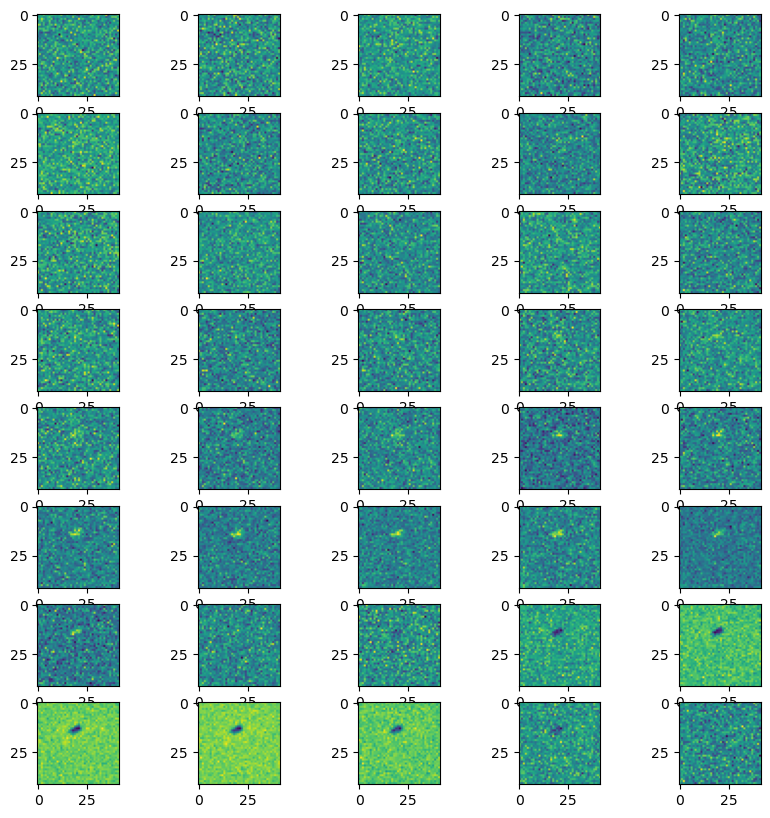

CPU times: user 695 ms, sys: 8 ms, total: 703 ms
Wall time: 2.66 s


In [15]:
%%time 

# ask the user to input a cell and plot its 3D sta (e.g., 1)
plot_one_cell_3D_spike_triggered_average(sta_data, checkerboard_spikes, cells_id)

### Cell 6 : Fitting ellipses

- **Requirements**: requires cell 1 run and cell 4 output
- Execution time: 10 secs

In [16]:
%%time 

# fit sta with ellipse
fit_ellipse_to_spike_triggered_average(checkerboard, check_directory, method="tom", fitted_sta_filename='sta_data_3D_fitted.pkl')

  0%|          | 0/344 [00:00<?, ?it/s]

 10%|▉         | 34/344 [00:00<00:07, 42.76it/s]

No ellipse fit on cell 28


 18%|█▊        | 63/344 [00:01<00:06, 42.22it/s]

No ellipse fit on cell 56


...

No ellipse fit on cell 255


 92%|█████████▏| 317/344 [00:07<00:00, 36.91it/s]

No ellipse fit on cell 311


100%|██████████| 344/344 [00:08<00:00, 39.78it/s]


CPU times: user 17.5 s, sys: 300 ms, total: 17.8 s
Wall time: 9.16 s


## Plotting STAs & their fitted ellipses

TODO!:
- save PSTAs and only plot a selected few, else kernel crashes - too memory intensive.

  0%|          | 0/344 [00:00<?, ?it/s]

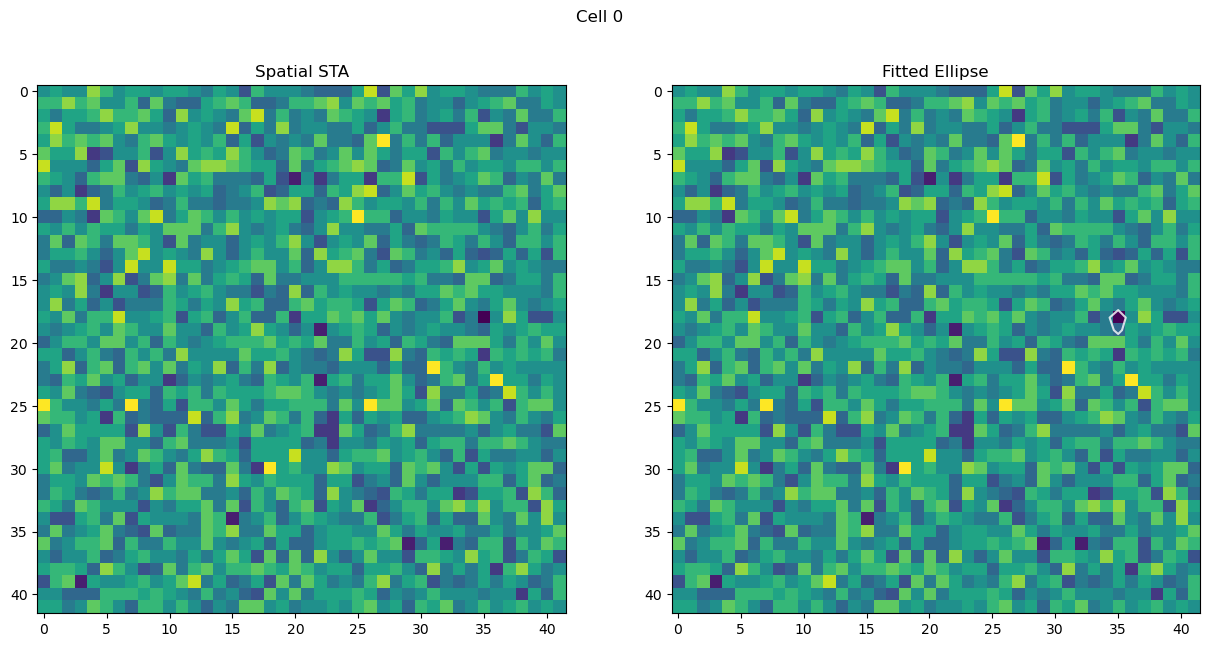

  0%|          | 1/344 [00:00<00:54,  6.26it/s]

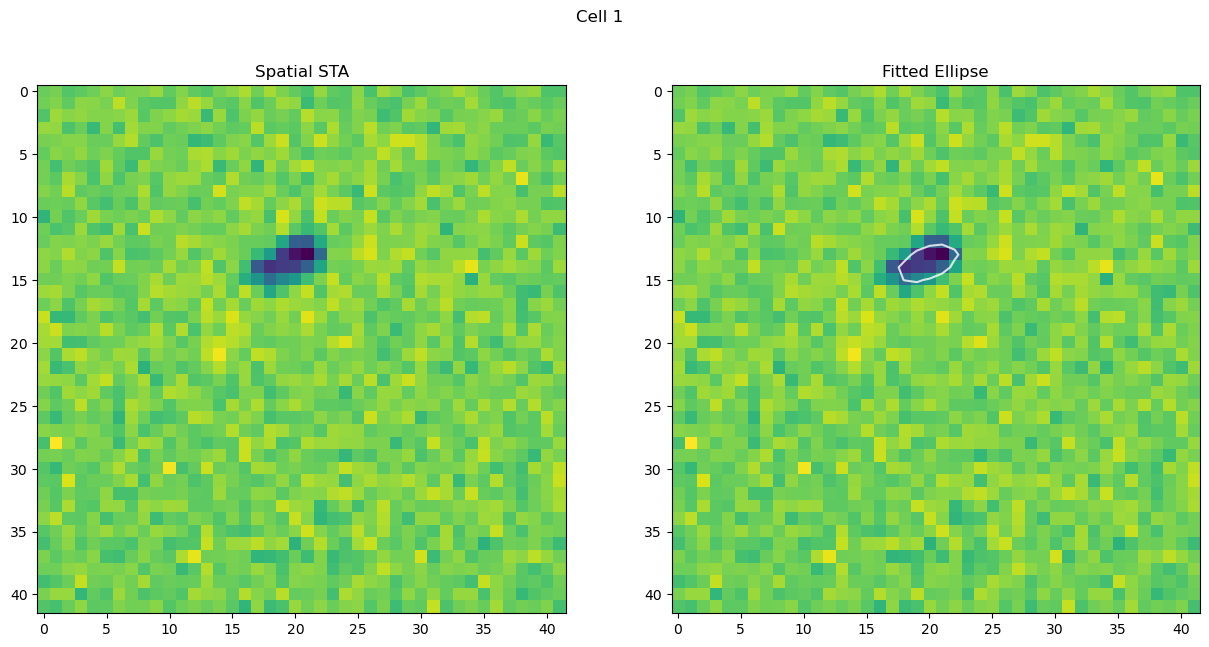

100%|██████████| 344/344 [00:33<00:00, 10.16it/s]

CPU times: user 33.8 s, sys: 222 ms, total: 34.1 s
Wall time: 34 s


In [18]:
%%time

plot_sta_fitted_with_ellipse(cells_id, cells_to_plot=[0,1], check_directory=check_directory)

## Plotting STAs & their fitted ellipses (New proposition by Tom)

In [ ]:
"""
    Plotting
"""

plot_sta_fitted_with_ellipse_by_tom(raster_data, cells_id, check_directory)



# Quantification of the number of STAs (not needed in the standard pipeline)

In [2]:
#The Goal of this cell is to quantify the number of STAs in your data
#Tuned to a 40x40 with square of 15 pixels checkerboard.
#Maybe, you need to tune it for your specific checkerboard
#See with Tom Quetu if needed for the tuning

print('')
nb_of_pixels_by_check = int(input("Select number of pixels by checks : ")) 

sta_data=np.load(os.path.join(check_directory,'sta_data_3D_fitted.pkl'),allow_pickle=True)
sta_quantification_dict={}

for cell in tqdm(cells_id[0:]):
    fig, ax = plt.subplots(nrows = 1,ncols = 1, figsize=(7,7))

    plt.suptitle(f'Cell {cell}')
    
    sta_spatial=sta_data[cell]["center_analyse"]['Spatial']
    ellipse_coor=sta_data[cell]["center_analyse"]['EllipseCoor']

    sta_quantification=check_presence_STA(sta_spatial,ellipse_coor,nb_of_pixels_by_check,tresh_snr=2.75)

    try:
        ax = plot_sta_tom(ax, sta_spatial,ellipse_coor)
    except: 
        ax.imshow(sta_spatial)

    color_cadr='r'
    if sta_quantification[0]==1:
        color_cadr='g'
        ax.set(title='STA with a SNR of ' + str(sta_quantification[1]))
    elif sta_quantification[0]==0.1:
        ax.set(title='ellipse not centered')
    elif sta_quantification[0]==0.2:
        ax.set(title='no ellipse fitted')
    elif sta_quantification[0]==0.3:
        ax.set(title='diameter too big or too small, diameter: ' + str(sta_quantification[1]) +'µm')
    elif sta_quantification[0]==0.4:
        ax.set(title='No STA because the SNR is too small, SNR:' + str(sta_quantification[1]))

    ax.spines['top'].set(lw=6, color=color_cadr)
    ax.spines['bottom'].set(lw=6, color=color_cadr)
    ax.spines['left'].set(lw=6, color=color_cadr)
    ax.spines['right'].set(lw=6, color=color_cadr)

    sta_quantification_dict[cell]=sta_quantification[0]
    plt.show()
    plt.close()

sta_quantif_dir=check_directory+'/sta_quantification'
save_obj(sta_quantification_dict,sta_quantif_dir)

NameError: name 'np' is not defined

# --------- end of the notebook---------------------------------------

# -----------work in progress---------------

### Cell 7 : Compare fits - Spatial STA

In [ ]:
"""
    Variable
    
    You will find here all variables used in this notebook cell. They should always refere to your 'params.py' file
    except if you want to manually change some variable only for this run (i.e. debugging). You may have to add those
    variable into the function you want to adapt as only the minimal amount of var are currently given to functions as inputs.
"""

output_directory = params.output_directory

"""
    Input
"""
# path = 'E:\Exp_17_for benchmark\RF_m1'


fitted_file = os.path.normpath(os.path.join(output_directory,'sta_data_3D_fitted.pkl'))

"""
    Processing
"""

sta_data = load_obj(fitted_file)

for cell_id in sta_data.keys():
    fig = plt.figure(figsize=(12,3))
    plt.subplots_adjust()
    fig.suptitle(f'Cell : {cell_id}')
    gs = GridSpec(1, 4, figure=fig)
    
#     png_image = np.array(Image.open(os.path.normpath(os.path.join(path,r'exp17_m1_clus{}_RF_STA_check.png'.format(cell_id)))))[74:472,132:530].transpose(1,0,2)
    matias  = sta_data[cell_id]["center_analyse"]  
#     gabriel = sta_data[cell_id]["surround_analyse"]
    mixed   = sta_data[cell_id]["analyse_sta"]
    
    try:
#         ax1 = fig.add_subplot(gs[0,0])
#         ax1.imshow(png_image)
#         ax1.set_title('Matlab')
        
        ax2 = fig.add_subplot(gs[0,1])
        ax2 = plot_sta(ax2, matias['Spatial'],matias['EllipseCoor'])       
        ax2.set_title('Matias')

#         ax3 = fig.add_subplot(gs[0,2])
#         ax3 = plot_sta(ax3, matias['Spatial'],gabriel['EllipseCoor'])    
#         ax3.set_title('Gabriel')
        
        ax4 = fig.add_subplot(gs[0,3])
        ax4 = plot_sta(ax4, mixed['Spatial'],mixed['EllipseCoor'])    
        ax4.set_title('Mixed')
        
        
    except:
        print(f'No print for cell {cell_id}')
        pass
    m=matias['EllipseCoor']
#     g=gabriel['EllipseCoor']
    mixed = mixed['EllipseCoor']
    print(f'matias : {m}')
#     print(f'gabriel : {g}')
    print(f'mixed : {mixed}')
    plt.show(block=False)

    print('--- Ploting Done ---')

In [ ]:
cell_id = 30

png_image = np.asarray(Image.open(os.path.normpath(os.path.join(path,r'exp17_m1_clus{}_RF_STA_check.png'.format(cell_id)))))[74:472,132:530].transpose(1,0,2)
matias  = sta_data[cell_id]["center_analyse"]  
gabriel = sta_data[cell_id]["surround_analyse"]
mixed   = sta_data[cell_id]["analyse_sta"]

fig = plt.figure(constrained_layout=True, figsize=(12,3))
gs = GridSpec(1, 4, figure=fig, wspace = 0)

ax1 = fig.add_subplot(gs[0,0])
ax1.imshow(png_image)
ax1.set_title('Matlab')

ax2 = fig.add_subplot(gs[0,1])
ax2 = plot_sta(ax2, matias['Spatial'],matias['EllipseCoor'])       
ax2.set_title('Matias')

ax3 = fig.add_subplot(gs[0,2])
ax3 = plot_sta(ax3, gabriel['Spatial'],gabriel['EllipseCoor'])    
ax3.set_title('Gabriel')

ax4 = fig.add_subplot(gs[0,3])
ax4 = plot_sta(ax4, mixed['Spatial'],mixed['EllipseCoor'])    
ax4.set_title('Mixed')

m=matias['EllipseCoor']
g=gabriel['EllipseCoor']
mixed = mixed['EllipseCoor']

print(f'matias : {m}')
print(f'gabriel : {g}')
print(f'mixed : {mixed}')

plt.show(block=False)

### Cell 8 : Compare fit - Temporal STA

In [ ]:
"""
    Variable
    
    You will find here all variables used in this notebook cell. They should always refere to your 'params.py' file
    except if you want to manually change some variable only for this run (i.e. debugging). You may have to add those
    variable into the function you want to adapt as only the minimal amount of var are currently given to functions as inputs.
"""

output_directory = params.output_directory

"""
    Input
"""

# path = 'E:\Exp_17_for benchmark\RF_m1'
fitted_file = os.path.normpath(os.path.join(output_directory,'sta_data_3D_fitted.pkl'))

"""
    Processing
"""

sta_data = load_obj(fitted_file)

for cell_id in sta_data.keys():
    
    fig = plt.figure(figsize=(9,3))
    plt.subplots_adjust()
    fig.suptitle(f'Cell : {cell_id}')
    gs = GridSpec(1, 3, figure=fig)
    
    matias  = sta_data[cell_id]["center_analyse"]  
#     gabriel = sta_data[cell_id]["surround_analyse"]
    mixed   = sta_data[cell_id]["analyse_sta"]
    
    try:        
        ax1 = fig.add_subplot(gs[0,0])
        ax1.plot(matias['Temporal'])
        ax1.axvline(matias['Cell_delay'])
        ax1.set_title('Matias')

#         ax2 = fig.add_subplot(gs[0,1])
#         ax2.plot(gabriel['Temporal'])  
#         ax2.axvline(gabriel['Cell_delay'])
#         ax2.set_title('Gabriel')
        
        ax3 = fig.add_subplot(gs[0,2])
        ax3.plot(mixed['Temporal'])
        ax3.axvline(mixed['Cell_delay'])
        ax3.set_title('Mixed')
        
        
    except:
        print(f'Print failed for cell {cell_id}')
        pass
    
    m=matias['EllipseCoor']
#     g=gabriel['EllipseCoor']
    mixed = mixed['EllipseCoor']
    
    print(f'matias : {m}')
#     print(f'gabriel : {g}')
    print(f'mixed : {mixed}')
    plt.show(block=False)
